In [1]:
import os

In [2]:
import pandas as pd 


In [3]:
import numpy as np 

In [4]:
import matplotlib.pyplot as plt 

In [5]:
import cv2

In [8]:
import warnings 
warnings.filterwarnings("ignore")

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

path to  train image folders

In [55]:
path_train = r"D:\[Adv]deep_learning\dataset\archive (4)\dataset\train"

In [56]:
path_test = r"D:\[Adv]deep_learning\dataset\archive (4)\dataset\test"

In [67]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [77]:
train_data = train_datagen.flow_from_directory(
    path_train,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)



Found 4187 images belonging to 6 classes.


In [79]:
test_data = test_datagen.flow_from_directory(
    path_test,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

Found 2698 images belonging to 6 classes.


In [80]:
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dense(6, activation='softmax')
])

In [81]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [85]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [84]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 646s 5s/step - accuracy: 0.6728 - loss: 0.8814 - val_accuracy: 0.6698 - val_loss: 1.1808
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 418s 3s/step - accuracy: 0.8474 - loss: 0.4321 - val_accuracy: 0.6920 - val_loss: 0.8661
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 355s 3s/step - accuracy: 0.8803 - loss: 0.3333 - val_accuracy: 0.7539 - val_loss: 0.7159
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 358s 3s/step - accuracy: 0.9057 - loss: 0.2463 - val_accuracy: 0.7839 - val_loss: 0.7726
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 854s 6s/step - accuracy: 0.9112 - loss: 0.2429 - val_accuracy: 0.8477 - val_loss: 0.4888
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 814s 6s/step - accuracy: 0.9219 - loss: 0.2022 - val_accuracy: 0.8217 - val_loss: 0.7046
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 739s 6s/step - accuracy: 0.9346 - loss: 0.1730 - val_accuracy: 0.8139 - val_loss: 0.6761
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 564s 4s/step - accuracy: 0.9417 - loss: 0.1534 - val_accu

In [76]:
print(train_data.class_indices)

{'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


In [86]:
import cv2
import numpy as np



error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'


In [88]:
import cv2
import numpy as np

img = cv2.imread(r"D:\[Adv]deep_learning\dataset\archive (4)\dataset\test\freshapples\rotated_by_15_Screen Shot 2018-06-08 at 4.59.49 PM.png")

if img is None:
    print("Image not found. Check path.")
else:
    img = cv2.resize(img,(150,150))
    img = img/255.0
    img = np.reshape(img,(1,150,150,3))

In [89]:
img1 = cv2.imread(r"D:\[Adv]deep_learning\dataset\archive (4)\dataset\test\freshapples\rotated_by_15_Screen Shot 2018-06-08 at 4.59.49 PM.png")

In [90]:
img1

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(402, 416, 3), dtype=uint8)

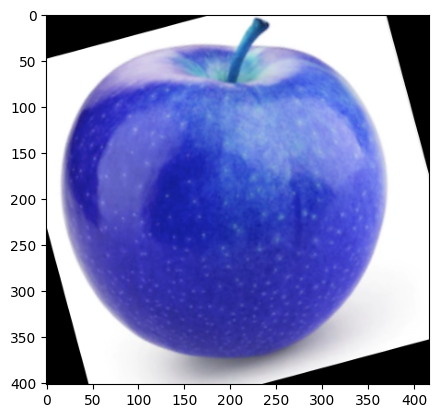

In [91]:
plt.imshow(img1)